# 채널·멀티호밍 분석

---

## 분석 개요

`06_channel`을 **SQL 중심 워크플로**로 구성한 분석이다. 채널 라벨·버킷·멀티호밍 분류와 분포·교차집계를 한 개의 SQL 파일 `../sql/06_channel.sql`에 모으고(쿼리별 `-- name:` 마커), 노트북은 이름으로 호출해 **시각화·해석**을 담당한다.

| 분석 단계 | 처리 위치 | 이유 |
|-----------|-----------|------|
| 인지(Q16)·구매영향(Q17) 라벨링, 분포, 성별·연령 교차, 멀티호밍 | **SQL** (`-- name:` 쿼리) | Q16·Q17은 단일응답 → 라벨·집계 SQL의 본령 |
| 인지=구매영향 일치 카이제곱 | **분할표는 SQL, 검정은 scipy** | 집계는 SQL, 검정은 Python |
| 멀티호밍별 NPS·구매빈도 만-휘트니 U | **점수는 SQL 뷰, 검정은 scipy** | 비모수 검정은 SQL 부적합 |

- 분석 대상: 플랫폼 사용자 200명 (`uses_platform='예'` AND `nps IS NOT NULL`)
- ⚠️ **데이터 한계**: 횡단면 자기보고. 인지·구매영향은 단일 선택이라 채널 간 상호작용은 측정되지 않으며, 멀티호밍은 Q4 플랫폼 복수선택 여부로 근사한다.


In [1]:
import os
from pathlib import Path
import re

import pandas as pd
import numpy as np
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

SQL_FILE = Path('../sql/06_channel.sql')

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)
print('로드된 쿼리:', list(Q))

def run(name):
    return pd.read_sql(Q[name], engine)

def execute(name):
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

로드된 쿼리: ['channel_view', 'base_scored', 'discovery_dist', 'influence_dist', 'discovery_by_gender', 'gender_by_influence', 'age_by_channel_type', 'discovery_influence_cross', 'channel_match', 'platform_group_dist', 'platform_group_by_nps']


---

## 0. SQL 채널·멀티호밍 뷰 구축

- `Q["channel_view"]` — 인지·구매영향 라벨, 인지 5분류, 연령 3구간, 채널 유형, NPS 세그먼트, 멀티호밍을 만드는 뷰(`channel_scored`).
- `Q["base_scored"]` — 행 단위 데이터(`df`). 만-휘트니 등 pandas 처리의 입력.


In [3]:
execute('channel_view')
df = run('base_scored')

n_users = len(df)
print(f'플랫폼 사용자: {n_users}명')
assert n_users == 200, f'모수 불일치: {n_users} (기대 200)'

플랫폼 사용자: 200명


---

## 1. 인지 경로 분포
- Q16. 지금 사용하는 패션 앱을 처음 알게 된 경로는 무엇인가요? (단일 응답)
---
**분석 질문 1** — 사용자는 어떤 경로로 패션 플랫폼을 처음 인지하는가?

- 분석 방법: 인지 경로별 응답자 수·비율 비교
- 분석 대상: 플랫폼 사용자 200명
- 보조 관찰: 성별에 따라 두드러지는 채널이 있는지 기술통계로 확인

In [4]:
# 인지 경로(Q16) 분포는 SQL에서 (discovery_dist — GROUP BY)
DISC_ORDER = ['SNS', '친구/지인', '포털 검색', '유튜브', '오프라인/미디어 광고', '앱스토어/플레이스토어', '기타/기억 안남']
disc_dist = (
    run('discovery_dist')
    .rename(columns={'인지경로': '인지 경로', 'pct': '비율(%)'})
    .set_index('인지 경로').reindex(DISC_ORDER, fill_value=0).reset_index()
)
disc_dist

,인지 경로,n,비율(%)
0,SNS,84,42.0
1,친구/지인,48,24.0
2,포털 검색,37,18.5
3,유튜브,23,11.5
4,오프라인/미디어 광고,3,1.5
5,앱스토어/플레이스토어,3,1.5
6,기타/기억 안남,2,1.0


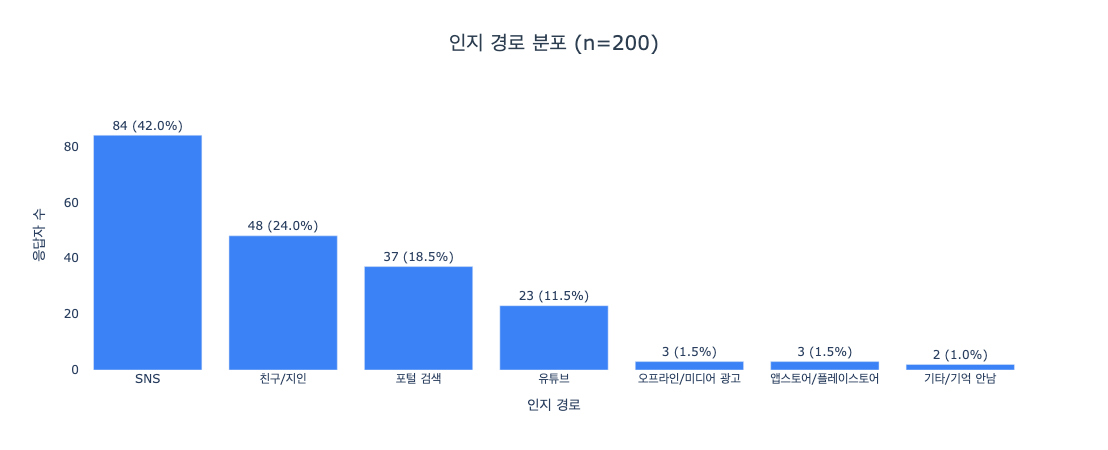

In [5]:
fig = go.Figure(go.Bar(
    x=disc_dist['인지 경로'],
    y=disc_dist['n'],
    text=[f"{n} ({p}%)" for n, p in zip(disc_dist['n'], disc_dist['비율(%)'])],
    textposition='outside',
    marker_color='#3B82F6',
))

fig.update_layout(
    title=dict(text=f'인지 경로 분포 (n={len(df)})', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='인지 경로',
    yaxis_title='응답자 수',
    yaxis=dict(range=[0, disc_dist['n'].max() * 1.15]),
    plot_bgcolor='white',
    height=450,
)
fig.show()

### 분석 질문 1 결과: SNS가 인지 경로에서 가장 높은 비중
_사용 SQL: `discovery_dist` — GROUP BY + 윈도우 비율_


**분포 요약**

- **SNS(인스타·틱톡·스레드) 84명(42.0%)** 으로 가장 높은 비중이다.
- 친구/지인 추천은 **48명(24.0%)**, 포털 검색은 **37명(18.5%)**, 유튜브는 **23명(11.5%)** 이다.
- 오프라인/미디어 광고 3명(1.5%)·앱스토어/플레이스토어 3명(1.5%)·기타/기억 안남 2명(1.0%)은 성별 보조 관찰에서 `기타`로 병합한다.
- SNS·유튜브·포털의 합산 인지 비중은 **144명(72.0%)** 이다.

---

### 보조 관찰 — 성별 인지 경로 분포

> 전체 성별 구성을 기준선으로 먼저 확인한 뒤, **성별 차이가 상대적으로 큰 인지 채널이 있는지** 점검한다.
>
> - 작은 카테고리 3개(오프라인 광고·앱스토어·기타)는 '기타'로 병합 
> - 정식 검정 없이 응답자 수와 행 비율만 비교하는 기술통계 보조 관찰
> - 사용자 200명 모수 그대로

In [6]:
gender_base = (
    df['gender'].value_counts()
    .reindex(['남성', '여성'])
    .rename_axis('성별')
    .reset_index(name='n')
)
gender_base['비율(%)'] = (gender_base['n'] / len(df) * 100).round(1)
display(gender_base)

,성별,n,비율(%)
0,남성,79,39.5
1,여성,121,60.5


In [7]:
# 인지 5분류 × 성별 교차도 SQL에서 (discovery_by_gender)
DISC_MERGED = ['SNS', '친구/지인', '포털 검색', '유튜브', '기타']
cross_dg = (
    run('discovery_by_gender')
    .pivot(index='discovery_grp', columns='gender', values='n')
    .reindex(index=DISC_MERGED)[['남성', '여성']].fillna(0).astype(int)
)
cross_dg

gender,남성,여성
discovery_grp,,
SNS,31,53
친구/지인,17,31
포털 검색,13,24
유튜브,15,8
기타,3,5


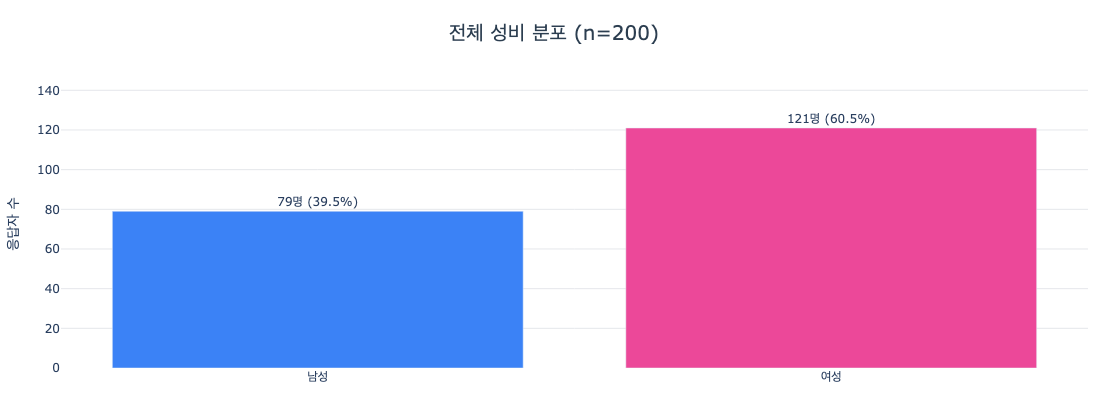

In [8]:
fig = go.Figure(go.Bar(
    x=gender_base['성별'],
    y=gender_base['n'],
    marker_color=['#3B82F6', '#EC4899'],
    text=[f"{int(n)}명 ({p:.1f}%)" for n, p in zip(gender_base['n'], gender_base['비율(%)'])],
    textposition='outside',
))

fig.update_layout(
    title=dict(
        text=f'전체 성비 분포 (n={len(df)})',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')
    ),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(title=''),
    yaxis=dict(gridcolor='#e5e7eb', title='응답자 수', range=[0, gender_base['n'].max() * 1.2]),
    width=600,
    height=420,
    margin=dict(l=20, r=20, t=80, b=40),
)

fig.show()

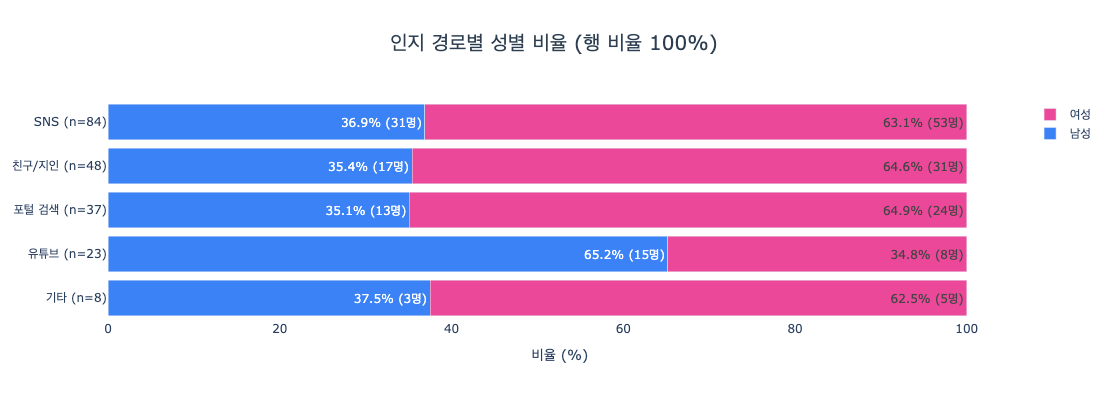

In [9]:
cross_pct = (cross_dg.div(cross_dg.sum(axis=1), axis=0) * 100).round(1)
disc_gender_labels = [f'{ch} (n={cross_dg.loc[ch].sum()})' for ch in DISC_MERGED]

fig = go.Figure()
fig.add_trace(go.Bar(
    name='남성', y=disc_gender_labels, x=cross_pct['남성'],
    orientation='h', marker_color='#3B82F6',
    text=[f"{p}% ({n}명)" for p, n in zip(cross_pct['남성'], cross_dg['남성'])], textposition='inside',
))
fig.add_trace(go.Bar(
    name='여성', y=disc_gender_labels, x=cross_pct['여성'],
    orientation='h', marker_color='#EC4899',
    text=[f"{p}% ({n}명)" for p, n in zip(cross_pct['여성'], cross_dg['여성'])], textposition='inside',
))

fig.update_layout(
    title=dict(text='인지 경로별 성별 비율 (행 비율 100%)',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    barmode='stack',
    xaxis_title='비율 (%)',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=400,
)
fig.show()

### 보조 관찰 결과 — 인지 채널은 전반적으로 성별 분포가 유사하고 유튜브는 남성 비중이 높음
_사용 SQL: `discovery_by_gender` — GROUP BY_


**전체 성별 기준선**: 남성 79명(39.5%) / 여성 121명(60.5%), n=200

**인지 경로별 성별 비율**

| 인지 경로 | 남성 | 여성 | 전체 남성 비율(39.5%) 대비 |
|----------|------|------|------------------------|
| SNS (n=84) | 36.9% | 63.1% | -2.6%p |
| 친구/지인 (n=48) | 35.4% | 64.6% | -4.1%p |
| 포털 검색 (n=37) | 35.1% | 64.9% | -4.4%p |
| **유튜브 (n=23)** | **65.2%** | **34.8%** | **+25.7%p** |
| 기타 (n=8) | 37.5% | 62.5% | -2.0%p (소표본) |

**보조 관찰 해석**
- SNS·친구/지인·포털의 남성 비율은 전체 남성 비율보다 2.6~4.4%p 낮아 차이가 크지 않다.
- 유튜브의 남성 비율은 전체보다 +25.7%p 높지만, 유튜브 인지자는 23명으로 표본이 작다.

> ### 섹션 결론
> - 인지 경로는 SNS **84명(42.0%)**, 친구/지인 **48명(24.0%)**, 포털 검색 **37명(18.5%)** 순이다.
> - SNS·친구/지인·포털 검색의 성별 구성은 전체 성별 분포와 큰 차이가 없고, 유튜브만 남성 비중이 **65.2%** 로 상대적으로 높다.
> - 다만 유튜브 인지자는 23명으로 표본이 작아, 성별 차이는 후속 표본에서 재확인할 보조 신호로 해석한다.

---

## 2. 구매 영향 채널 분포
- Q17. 최근 6개월 내 패션 상품 구매에 가장 영향을 준 채널은 무엇인가요? (단일 응답)
---
**분석 질문 2** — 최근 6개월 구매에 영향을 준 채널은 어떻게 분포하는가?

- 분석 방법: 구매 영향 채널별 응답자 수·비율 비교
- 분석 대상: 플랫폼 사용자 200명
- 보조 관찰: 연령대별 외부(SNS·유튜브·친구/지인)와 앱 내(추천·푸시) 채널 비율 비교

In [10]:
# 구매 영향 채널(Q17) 분포는 SQL에서 (influence_dist — GROUP BY)
INF_ORDER = ['SNS', '유튜브', '친구/지인', '앱 내 추천', '앱 푸시/쿠폰', '특별히 없음']
inf_dist = (
    run('influence_dist')
    .rename(columns={'구매영향채널': '구매 영향 채널', 'pct': '비율(%)'})
    .set_index('구매 영향 채널').reindex(INF_ORDER).reset_index()
)
inf_dist

,구매 영향 채널,n,비율(%)
0,SNS,71,35.5
1,유튜브,49,24.5
2,친구/지인,17,8.5
3,앱 내 추천,18,9.0
4,앱 푸시/쿠폰,12,6.0
5,특별히 없음,33,16.5


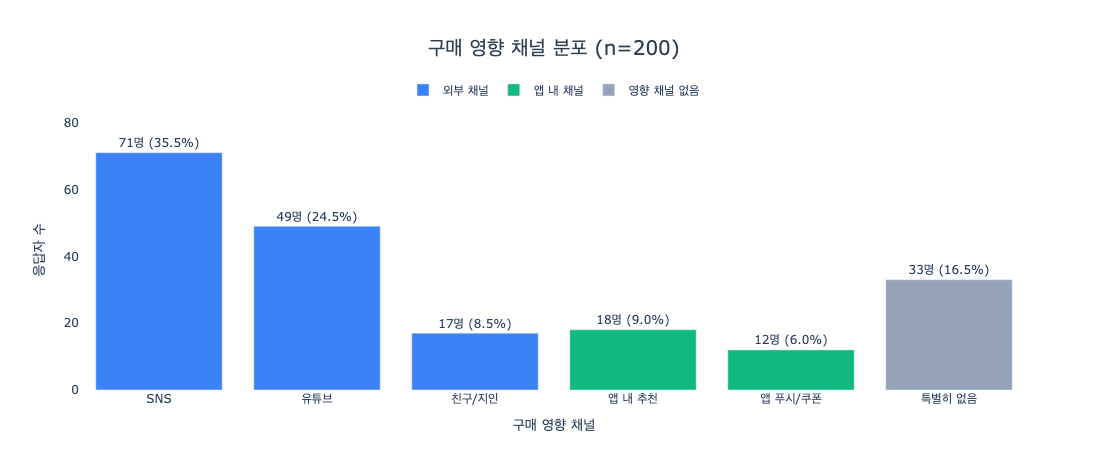

In [11]:
INF_TYPE = {
    'SNS': '외부', '유튜브': '외부', '친구/지인': '외부',
    '앱 내 추천': '앱 내', '앱 푸시/쿠폰': '앱 내',
    '특별히 없음': '없음',
}
TYPE_COLOR = {'외부': '#3B82F6', '앱 내': '#10B981', '없음': '#94A3B8'}

TYPE_LABEL = {'외부': '외부 채널', '앱 내': '앱 내 채널', '없음': '영향 채널 없음'}

fig = go.Figure()
for channel_type in ['외부', '앱 내', '없음']:
    subset = inf_dist[
        inf_dist['구매 영향 채널'].map(INF_TYPE) == channel_type
    ]
    fig.add_trace(go.Bar(
        name=TYPE_LABEL[channel_type],
        x=subset['구매 영향 채널'],
        y=subset['n'],
        text=[f"{n}명 ({p}%)" for n, p in zip(subset['n'], subset['비율(%)'])],
        textposition='outside',
        marker_color=TYPE_COLOR[channel_type],
    ))

fig.update_layout(
    title=dict(text=f'구매 영향 채널 분포 (n={len(df)})',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis=dict(title='구매 영향 채널', categoryorder='array', categoryarray=INF_ORDER),
    yaxis_title='응답자 수',
    yaxis=dict(range=[0, inf_dist['n'].max() * 1.18]),
    plot_bgcolor='white',
    barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    margin=dict(t=110),
    height=470,
)
fig.show()

### 분석 질문 2 결과: SNS와 유튜브가 구매 영향 채널의 1·2위
_사용 SQL: `influence_dist` — GROUP BY + 윈도우 비율_


**분포 요약**

- SNS는 **71명(35.5%)**, 유튜브는 **49명(24.5%)** 으로 구매 영향 채널의 1·2위다.
- 특별히 없음은 **33명(16.5%)**, 앱 내 추천·푸시는 합계 **30명(15.0%)**, 친구/지인은 **17명(8.5%)** 이다.

**인지 경로(Q16)와 구매 영향 채널(Q17) 응답 비중 비교**
- 유튜브는 11.5%에서 24.5%로 구매 영향 응답 비중이 높고, 친구/지인은 24.0%에서 8.5%로 낮다.
- SNS는 인지 42.0%, 구매 영향 35.5%로 두 문항 모두에서 가장 높은 비중이다.

---

### 보조 관찰 — 성별·연령대 × 구매 영향 채널

> 전체 구매 영향 채널을 성별로 비교하고, 외부·앱 내 채널 유형을 연령대별로 나눠 보조적으로 살펴본다.
>
> - 성별: 구매 영향 6채널 구성비 비교(전체 사용자 200명)
> - 연령대: 외부(SNS·유튜브·친구/지인) / 앱 내(추천·푸시) / 특별히 없음의 3범주 비교(전체 200명)
> - 연령 그룹: 10-20대 초중반 / 20대 후반 / 30대 이상 (작은 셀 방지)
> - 정식 검정 없이 응답자 수와 행 비율만 비교하는 기술통계 보조 관찰

In [12]:
# 성별 × 구매 영향 채널 교차도 SQL에서 (gender_by_influence)
cross_gi = (
    run('gender_by_influence')
    .pivot(index='gender', columns='influence', values='n')
    .reindex(['남성', '여성'])[INF_ORDER].fillna(0).astype(int)
)
cross_gi

influence,SNS,유튜브,친구/지인,앱 내 추천,앱 푸시/쿠폰,특별히 없음
gender,,,,,,
남성,22,28,6,5,4,14
여성,49,21,11,13,8,19


In [13]:
# 연령 3구간 × 채널 유형 교차도 SQL에서 (age_by_channel_type)
AGE_GROUP_ORDER = ['10-20대 초중반', '20대 후반', '30대 이상']
cross_ea = (
    run('age_by_channel_type')
    .pivot(index='age_group', columns='channel_type', values='n')
    .reindex(AGE_GROUP_ORDER)[['외부', '앱 내', '특별히 없음']].fillna(0).astype(int)
)
df_age_channel = df   # 뒤 시각화 제목의 n 표기에만 사용
cross_ea

channel_type,외부,앱 내,특별히 없음
age_group,,,
10-20대 초중반,61,12,13
20대 후반,51,8,10
30대 이상,25,10,10


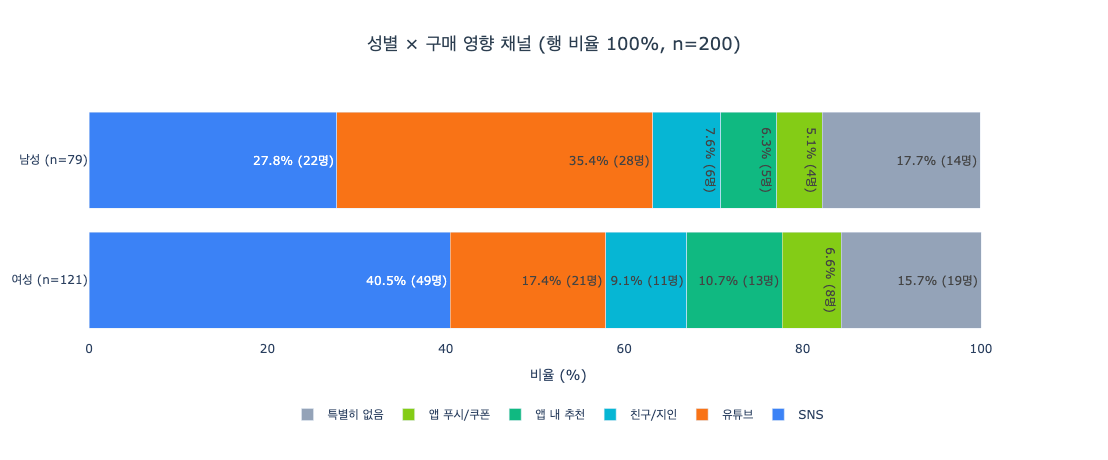

In [14]:
INF_CHANNEL_COLOR = {
    'SNS': '#3B82F6', '유튜브': '#F97316', '친구/지인': '#06B6D4',
    '앱 내 추천': '#10B981', '앱 푸시/쿠폰': '#84CC16', '특별히 없음': '#94A3B8',
}
cross_gi_pct = (cross_gi.div(cross_gi.sum(axis=1), axis=0) * 100).round(1)
gender_labels = [f'{g} (n={cross_gi.loc[g].sum()})' for g in ['남성', '여성']]

fig_gender = go.Figure()
for channel in INF_ORDER:
    fig_gender.add_trace(go.Bar(
        name=channel,
        y=gender_labels,
        x=cross_gi_pct[channel],
        orientation='h',
        marker_color=INF_CHANNEL_COLOR[channel],
        text=[f'{p}% ({int(n)}명)' for p, n in zip(cross_gi_pct[channel], cross_gi[channel])],
        textposition='inside',
    ))

fig_gender.update_layout(
    title=dict(text=f'성별 × 구매 영향 채널 (행 비율 100%, n={len(df)})',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='stack',
    xaxis_title='비율 (%)',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=460,
    legend=dict(orientation='h', yanchor='top', y=-0.25, xanchor='center', x=0.5),
    margin=dict(b=120),
)
fig_gender.show()

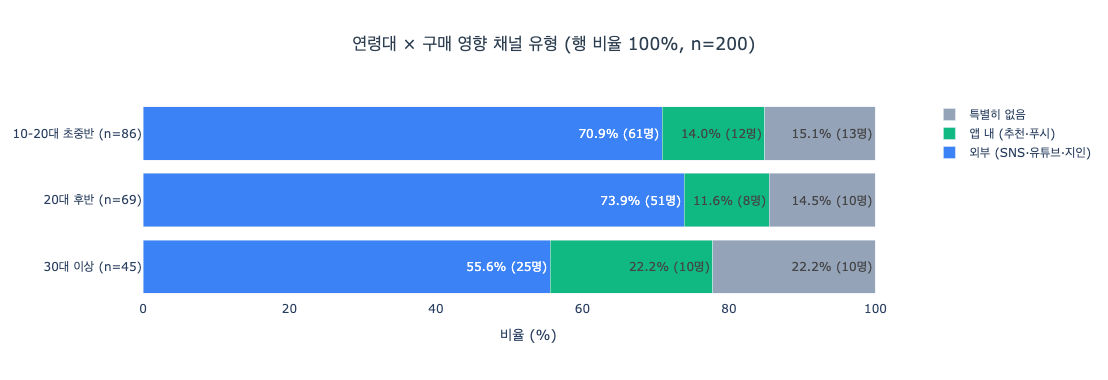

In [15]:
cross_ea_pct = (cross_ea.div(cross_ea.sum(axis=1), axis=0) * 100).round(1)
age_channel_labels = [f'{age} (n={cross_ea.loc[age].sum()})' for age in AGE_GROUP_ORDER]

fig = go.Figure()
fig.add_trace(go.Bar(
    name='외부 (SNS·유튜브·지인)', y=age_channel_labels, x=cross_ea_pct['외부'],
    orientation='h', marker_color='#3B82F6',
    text=[f"{p}% ({n}명)" for p, n in zip(cross_ea_pct['외부'], cross_ea['외부'])], textposition='inside',
))
fig.add_trace(go.Bar(
    name='앱 내 (추천·푸시)', y=age_channel_labels, x=cross_ea_pct['앱 내'],
    orientation='h', marker_color='#10B981',
    text=[f"{p}% ({n}명)" for p, n in zip(cross_ea_pct['앱 내'], cross_ea['앱 내'])], textposition='inside',
))
fig.add_trace(go.Bar(
    name='특별히 없음', y=age_channel_labels, x=cross_ea_pct['특별히 없음'],
    orientation='h', marker_color='#94A3B8',
    text=[f"{p}% ({n}명)" for p, n in zip(cross_ea_pct['특별히 없음'], cross_ea['특별히 없음'])], textposition='inside',
))

fig.update_layout(
    title=dict(text=f'연령대 × 구매 영향 채널 유형 (행 비율 100%, n={len(df_age_channel)})',
               x=0.5, xanchor='center', font=dict(size=17, color='#2c3e50')),
    barmode='stack',
    xaxis_title='비율 (%)',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=380,
)
fig.show()

### 보조 관찰 결과 — 남성은 유튜브, 여성은 SNS 비중이 높고 30대 이상은 앱 내·특별히 없음 비중이 상대적으로 큼
_사용 SQL: `gender_by_influence` · `age_by_channel_type` — GROUP BY_


**성별 구매 영향 채널 구성** (n=200)

| 성별 | SNS | 유튜브 | 친구/지인 | 앱 내 추천 | 앱 푸시/쿠폰 | 특별히 없음 |
|---|---:|---:|---:|---:|---:|---:|
| 남성 (n=79) | 27.8% (22명) | **35.4% (28명)** | 7.6% (6명) | 6.3% (5명) | 5.1% (4명) | 17.7% (14명) |
| 여성 (n=121) | **40.5% (49명)** | 17.4% (21명) | 9.1% (11명) | 10.7% (13명) | 6.6% (8명) | 15.7% (19명) |

- 남성은 유튜브 비중이 여성보다 18.0%p 높고, 여성은 SNS 비중이 남성보다 12.7%p 높다.

**연령대별 채널 유형 비율** (n=200)

| 연령대 | 외부 | 앱 내 | 특별히 없음 |
|--------|------|-------|-------------|
| 10-20대 초중반 (n=86) | 70.9% (61명) | 14.0% (12명) | 15.1% (13명) |
| 20대 후반 (n=69) | **73.9% (51명)** | 11.6% (8명) | 14.5% (10명) |
| **30대 이상 (n=45)** | 55.6% (25명) | **22.2% (10명)** | **22.2% (10명)** |

**보조 관찰 해석**
- 모든 연령에서 외부 채널 비중이 가장 높고, 30대 이상은 앱 내·특별히 없음 비중이 각각 22.2%로 다른 연령대보다 높다.
- 성별·연령 차이는 정식 검정 없이 확인한 기술통계 신호다.

> ### 섹션 결론
> - 구매 영향 채널은 전체 기준으로 SNS **71명(35.5%)**, 유튜브 **49명(24.5%)**, 특별히 없음 **33명(16.5%)** 순이다.
> - 성별로는 남성에서 유튜브 **35.4%**, 여성에서 SNS **40.5%** 가 가장 높고, 30대 이상은 앱 내와 특별히 없음이 각각 **22.2%** 로 나타난다.
> - 성별·연령 차이는 기술통계 기반 보조 관찰이며, 운영 판단보다 반복 표본에서 재현 여부를 확인하는 용도로 활용한다.

---

## 3. 인지 경로와 구매 영향 채널의 연결
- Q16. 지금 사용하는 패션 앱을 처음 알게 된 경로는 무엇인가요?
- Q17. 최근 6개월 내 패션 상품 구매에 가장 영향을 준 채널은 무엇인가요?

---

**분석 질문 3** — 인지 경로와 구매 영향 채널은 같은 응답자 안에서 어떻게 연결되는가?

- 분석 방법: 전체 교차표의 행 비율 시각화 + 공통 3채널의 동일 채널 여부 카이제곱 검정
- 분석 대상: 전체 사용자 200명; 동일 채널 검정은 SNS·유튜브·친구/지인 인지자 155명
- 해석 기준: 회상 기반 두 문항의 응답 연결이며 실제 전환율이나 시간 순서를 의미하지 않음

In [16]:
# 인지 5분류 × 구매 영향 채널 교차도 SQL에서 (discovery_influence_cross)
DISC_FULL = ['SNS', '유튜브', '친구/지인', '포털 검색', '기타']
INF_FULL = ['SNS', '유튜브', '친구/지인', '앱 내 추천', '앱 푸시/쿠폰', '특별히 없음']
cross_di = (
    run('discovery_influence_cross')
    .pivot(index='discovery_grp', columns='influence', values='n')
    .reindex(index=DISC_FULL, columns=INF_FULL, fill_value=0).fillna(0).astype(int)
)
cross_di_pct = (cross_di.div(cross_di.sum(axis=1), axis=0) * 100).round(1)
cross_di

influence,SNS,유튜브,친구/지인,앱 내 추천,앱 푸시/쿠폰,특별히 없음
discovery_grp,,,,,,
SNS,48,17,3,4,2,10
유튜브,2,14,3,0,1,3
친구/지인,12,8,10,4,4,10
포털 검색,8,8,1,8,4,8
기타,1,2,0,2,1,2


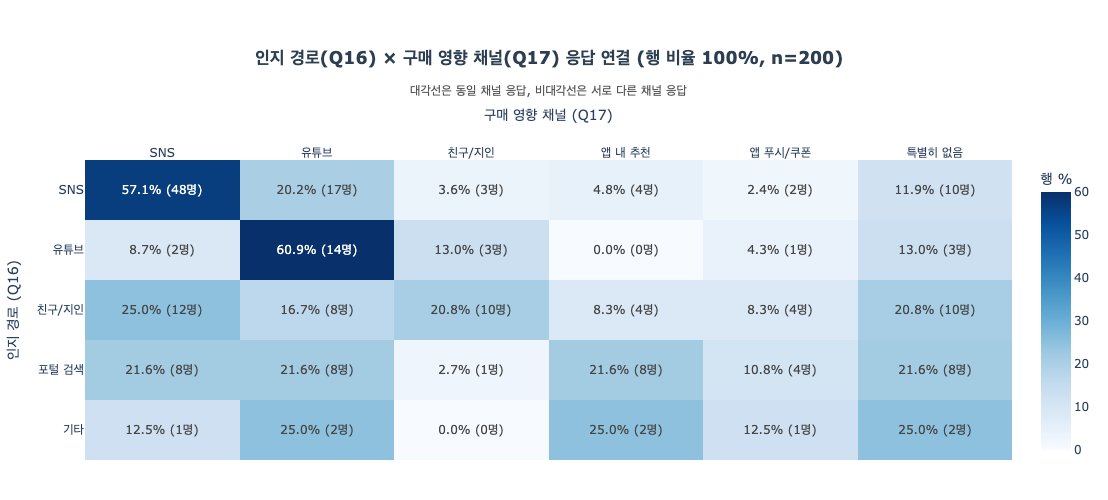

In [17]:
fig = go.Figure(go.Heatmap(
    z=cross_di_pct.values,
    x=INF_FULL,
    y=DISC_FULL,
    text=[[f"{pct}% ({int(n)}명)" for pct, n in zip(pct_row, n_row)]
          for pct_row, n_row in zip(cross_di_pct.values, cross_di.values)],
    texttemplate='%{text}',
    textfont=dict(size=12),
    colorscale='Blues',
    zmin=0, zmax=60,
    colorbar=dict(title='행 %'),
))

fig.update_layout(
    title=None,
    annotations=[
        dict(
            text=f'<b>인지 경로(Q16) × 구매 영향 채널(Q17) 응답 연결 (행 비율 100%, n={len(df)})</b>',
            xref='paper', yref='paper',
            x=0.5, y=1.30, 
            showarrow=False,
            xanchor='center', yanchor='bottom',
            font=dict(size=17, color='#2c3e50')
        ),
        dict(
            text='대각선은 동일 채널 응답, 비대각선은 서로 다른 채널 응답',
            xref='paper', yref='paper',
            x=0.5, y=1.20,  
            showarrow=False,
            xanchor='center', yanchor='bottom',
            font=dict(size=12, color='#555555')
        )
    ],
    xaxis=dict(
        title=dict(
            text='구매 영향 채널 (Q17)',
            standoff=20 
        ), 
        side='top'
    ),
    yaxis=dict(title='인지 경로 (Q16)', autorange='reversed'),
    plot_bgcolor='white',
    margin=dict(t=160, b=40, l=40, r=40), 
    height=500 
)

fig.show()

In [18]:
# 인지(공통 채널) × 동일채널 구매영향 여부도 SQL에서 (channel_match — 조건부 집계)
COMMON_CH = ['SNS', '유튜브', '친구/지인']
match_df = (
    run('channel_match')
    .rename(columns={'인지채널': '인지 채널', 'n': '인지자 수', '일치': '동일 채널 구매 영향'})
    .set_index('인지 채널').reindex(COMMON_CH).reset_index()
)
match_df['일치율(%)'] = (match_df['동일 채널 구매 영향'] / match_df['인지자 수'] * 100).round(1)
match_df = match_df[['인지 채널', '인지자 수', '동일 채널 구매 영향', '일치율(%)']]
match_df

,인지 채널,인지자 수,동일 채널 구매 영향,일치율(%)
0,SNS,84,48.0,57.1
1,유튜브,23,14.0,60.9
2,친구/지인,48,10.0,20.8


---

> **동일 채널 여부 검정 설계**
>
> 공통 3채널(SNS·유튜브·친구/지인) 인지자 155명을 대상으로, 구매 영향 채널이 인지 채널과 같은지를 `일치/불일치`로 구분한다.
>
> | 인지 채널 | 동일 채널 구매 | 다른 채널 구매 | 일치율 |
> |---|---:|---:|---:|
> | SNS | 48명 | 36명 | 57.1% |
> | 유튜브 | 14명 | 9명 | 60.9% |
> | 친구/지인 | 10명 | 38명 | 20.8% |
>
> - 검정: 인지 채널 3개 × 동일 채널 여부 2개 카이제곱 독립성 검정
> - 유의수준: α=0.05
> - 장점: 의미가 다른 앱 내 추천·푸시·특별히 없음을 하나의 범주로 병합하지 않고, 분석 질문인 동일 채널 응답률 차이를 직접 검정

In [19]:
# 카이제곱 입력 분할표도 SQL 카운트에서 구성 (검정은 scipy)
cross_match = (
    run('channel_match')
    .set_index('인지채널')[['일치', '불일치']]
    .reindex(COMMON_CH).fillna(0).astype(int)
)
cross_match

,일치,불일치
인지채널,,
SNS,48,36
유튜브,14,9
친구/지인,10,38


In [20]:
chi2_s, p_s, dof_s, expected_s = stats.chi2_contingency(cross_match)
n_total_s = cross_match.values.sum()
cramer_v_s = np.sqrt(chi2_s / (n_total_s * (min(cross_match.shape) - 1)))
n_below5_s = (expected_s < 5).sum()

print(f'Chi² = {chi2_s:.4f}')
print(f'p-value = {p_s:.6f}')
print(f'dof = {dof_s}')
print(f"Cramér's V = {cramer_v_s:.4f}")
print(f'기대빈도 5 미만 셀: {n_below5_s} / {expected_s.size} ({n_below5_s/expected_s.size*100:.1f}%)')
print(f'분석 대상 n = {n_total_s}')

Chi² = 18.4468
p-value = 0.000099
dof = 2
Cramér's V = 0.3450
기대빈도 5 미만 셀: 0 / 6 (0.0%)
분석 대상 n = 155


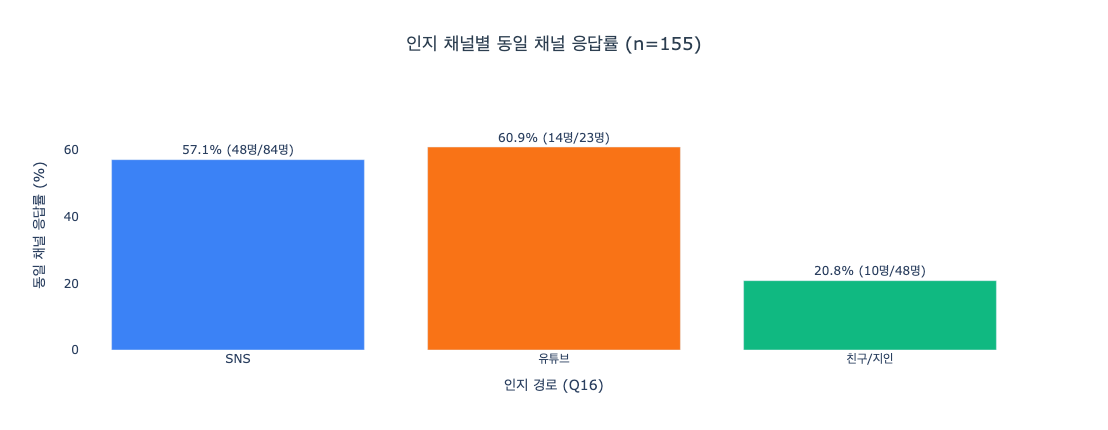

In [21]:
match_rate = (cross_match['일치'] / cross_match.sum(axis=1) * 100).round(1)
match_n = cross_match.sum(axis=1)

fig = go.Figure(go.Bar(
    x=COMMON_CH,
    y=match_rate.reindex(COMMON_CH),
    text=[f'{match_rate[ch]:.1f}% ({cross_match.loc[ch, "일치"]}명/{match_n[ch]}명)' for ch in COMMON_CH],
    textposition='outside',
    marker_color=['#3B82F6', '#F97316', '#10B981'],
))
fig.update_layout(
    title=dict(text=f'인지 채널별 동일 채널 응답률 (n={n_total_s})',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    xaxis_title='인지 경로 (Q16)',
    yaxis=dict(title='동일 채널 응답률 (%)', range=[0, 75]),
    plot_bgcolor='white',
    height=430,
)
fig.show()

### 분석 질문 3 결과: 동일 채널 응답률은 SNS·유튜브에서 높고 친구/지인에서 낮음
_분할표 SQL: `channel_match` (조건부 집계) · 검정: scipy 카이제곱_


**공통 3채널 인지자 155명 × 동일 채널 여부 카이제곱 검정 (3×2)**

| 지표 | 값 | 해석 |
|---|---:|---|
| Chi² | **18.447** | df=2 |
| p-value | **<0.001** | 인지 채널별 동일 채널 응답률에 차이가 있음 |
| Cramér's V | **0.345** | 중간 수준의 연관성 |
| 기대빈도 5 미만 셀 | **0/6 (0.0%)** | 카이제곱 근사 가정 충족 |
| 분석 대상 | **155명** | SNS·유튜브·친구/지인 인지자 |

> ### 섹션 결론
> - 인지 경로별 동일 채널 응답률에는 차이가 있으며(Chi²=**18.447**, p<**0.001**, V=**0.345**), 친구/지인은 **20.8%** 로 SNS·유튜브보다 낮다.
> - 이 결과는 `02_eda`의 채널 분포를 동일 응답자 안의 연결 구조로 확장한 분석이다.
> - 다만 회상 기반 설문은 실제 고객 여정을 직접 측정하지 않으므로, 유입·노출·구매 로그로 후속 확인하는 편이 안전하다.

---

## 4. 멀티호밍 분석
- Q6. 현재 가장 자주 사용하는 패션 관련 플랫폼을 1~2개 선택해주세요.

멀티호밍 여부에 따른 사용자 분포를 먼저 확인하고, 이어서 추천 의향·구매 행동과의 관계를 살펴본다.

---

## 4-1. 멀티호밍 분포

**분석 질문 4-1** — 단일·복수 플랫폼 사용자는 어떻게 분포하는가?

- 분석 방법: 멀티호밍 그룹별 응답자 수·비율 비교
- 분석 대상: 플랫폼 사용자 200명
- 해석 기준: 정확한 플랫폼 개수 비교가 아닌 단일/복수 플랫폼 이진 구분

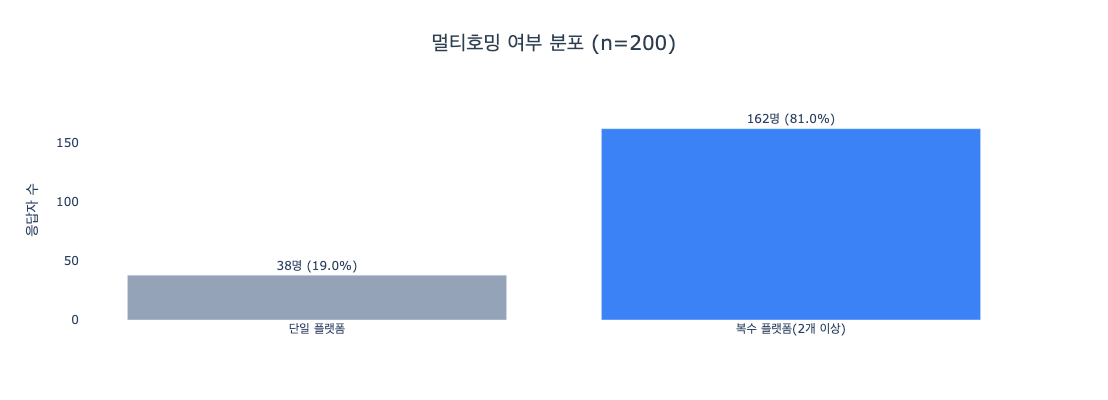

In [22]:
# 멀티호밍 분포는 SQL에서 (platform_group_dist — GROUP BY)
pc_dist = (
    run('platform_group_dist')
    .sort_values('platform_group').reset_index(drop=True)
)
pc_dist.columns = ['멀티호밍 구분', 'n', '비율(%)']
pc_dist['라벨'] = pc_dist['멀티호밍 구분'].map({1: '단일 플랫폼', 2: '복수 플랫폼(2개 이상)'})

fig = go.Figure(go.Bar(
    x=pc_dist['라벨'],
    y=pc_dist['n'],
    text=[f"{n}명 ({p}%)" for n, p in zip(pc_dist['n'], pc_dist['비율(%)'])],
    textposition='outside',
    marker_color=['#94A3B8', '#3B82F6'],
))
fig.update_layout(
    title=dict(text=f'멀티호밍 여부 분포 (n={len(df)})',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='', yaxis_title='응답자 수',
    yaxis=dict(range=[0, pc_dist['n'].max() * 1.15]),
    plot_bgcolor='white', height=400,
)
fig.show()

### 분석 질문 4-1 결과: 복수 플랫폼 사용자가 전체의 81.0%
_사용 SQL: `platform_group_dist` — GROUP BY + 윈도우 비율_


**분포 요약**

- **복수 플랫폼 사용자 162명(81.0%)**: 응답자 다수가 2개 이상의 플랫폼을 함께 사용한다.
- **단일 플랫폼 사용자 38명(19.0%)**: 한 개 플랫폼만 사용하는 응답자는 약 5명 중 1명이다.
- `01_cleaning`에서 복합 자유입력 응답을 개별 플랫폼으로 분리하면서 3개 항목으로 정규화된 사례가 있어, 정확한 앱 개수 대신 `단일/복수(2개 이상)`로 구분한다.

> ### 섹션 결론
> - 복수 플랫폼 사용자는 **162명(81.0%)** 으로 조사 응답자의 다수를 차지한다.
> - 단일 플랫폼 사용자는 **38명(19.0%)** 으로 약 5명 중 1명이다.
> - 이 분류는 정확한 앱 개수가 아닌 단일/복수 이진 구분이며, 시장 전체의 경쟁 구조로 일반화하지 않는다.

---

## 4-2. 멀티호밍과 추천 의향·구매 빈도
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요?
- Q15. 현재 사용하는 패션 플랫폼을 지인에게 추천할 의향이 얼마나 있나요?

**분석 질문 4-2** — 멀티호밍 여부에 따라 추천 의향의 구성과 구매 빈도에 어떤 차이가 나타나는가?

- 분석 방법: NPS 세그먼트 구성은 기술통계, 추천점수는 Mann-Whitney U와 rank-biserial r, 구매 빈도는 Mann-Whitney U와 rank-biserial r로 확인
- 분석 대상: 단일 플랫폼 38명, 복수 플랫폼 162명
- 해석 기준: 통계적 유의성과 효과 크기를 함께 보고, 단면 설문이므로 인과관계는 주장하지 않음

---

### NPS 세그먼트 구성

> 단일·복수 플랫폼 그룹의 NPS 세그먼트 구성을 시각화해 분포 차이를 확인한다.
>
> - 세그먼트 정의는 `03_nps` 동일 기준 (Detractor 0-6 / Passive 7-8 / Promoter 9-10) — SQL의 `nps_segment` 컬럼 그대로 사용
> - 세그먼트 비율은 기술통계로 해석하며, 이어지는 추천점수 원점수 검정과 함께 확인

In [23]:
# 멀티호밍 × NPS 세그먼트 교차도 SQL에서 (platform_group_by_nps)
SEGMENT_ORDER = ['Detractor', 'Passive', 'Promoter']
cross_ns = (
    run('platform_group_by_nps')
    .pivot(index='platform_group', columns='nps_segment', values='n')
    .reindex([1, 2])[SEGMENT_ORDER].fillna(0).astype(int)
)
cross_ns

nps_segment,Detractor,Passive,Promoter
platform_group,,,
1,23,12,3
2,65,76,21


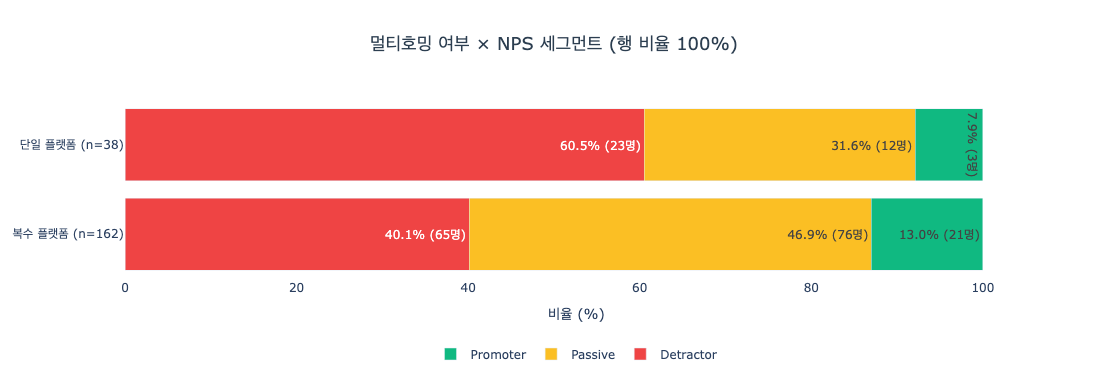

In [24]:
SEGMENT_COLOR = ['#EF4444', '#FBBF24', '#10B981']

cross_ns_pct = (cross_ns.div(cross_ns.sum(axis=1), axis=0) * 100).round(1)

fig = go.Figure()
for i, seg in enumerate(SEGMENT_ORDER):
    fig.add_trace(go.Bar(
        name=seg,
        y=[f'단일 플랫폼 (n={cross_ns.loc[1].sum()})', f'복수 플랫폼 (n={cross_ns.loc[2].sum()})'],
        x=cross_ns_pct[seg],
        orientation='h',
        marker_color=SEGMENT_COLOR[i],
        text=[f"{p}% ({int(n)}명)" for p, n in zip(cross_ns_pct[seg], cross_ns[seg])],
        textposition='inside',
    ))

fig.update_layout(
    title=dict(text='멀티호밍 여부 × NPS 세그먼트 (행 비율 100%)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='stack',
    xaxis_title='비율 (%)',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=380,
    legend=dict(orientation='h', yanchor='bottom', y=-0.5, xanchor='center', x=0.5),
)
fig.show()

---

### 추천점수 원점수 비교

NPS 세그먼트 구성에서 보인 차이를 Q15 추천점수 원점수에서도 점검한다. 두 독립 그룹의 점수 순위를 Mann-Whitney U로 비교하고, rank-biserial r로 효과 크기를 함께 제시한다.

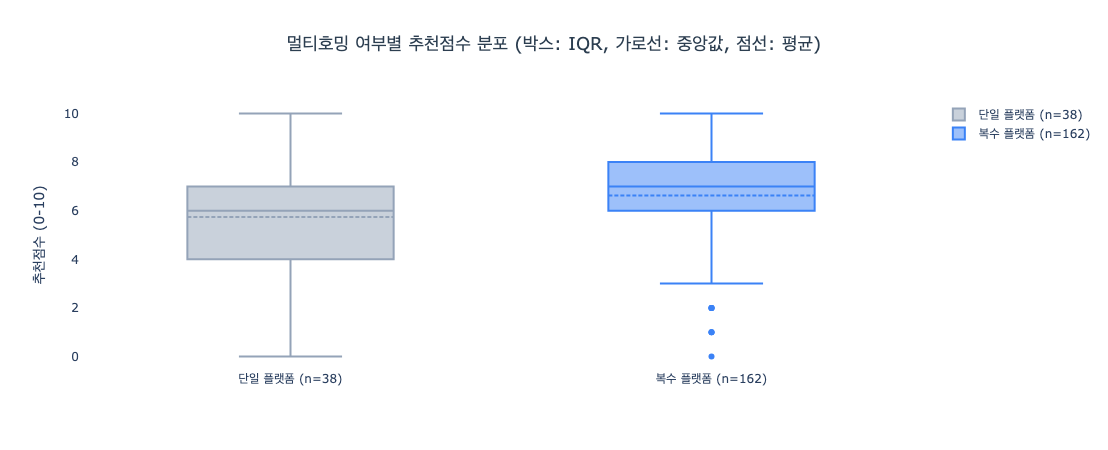

In [25]:
nps_1 = df[df['platform_group'] == 1]['nps']
nps_2 = df[df['platform_group'] == 2]['nps']

fig = go.Figure()
fig.add_trace(go.Box(
    y=nps_1, name=f'단일 플랫폼 (n={len(nps_1)})',
    marker_color='#94A3B8', boxmean=True,
))
fig.add_trace(go.Box(
    y=nps_2, name=f'복수 플랫폼 (n={len(nps_2)})',
    marker_color='#3B82F6', boxmean=True,
))

fig.update_layout(
    title=dict(text='멀티호밍 여부별 추천점수 분포 (박스: IQR, 가로선: 중앙값, 점선: 평균)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    yaxis_title='추천점수 (0-10)',
    plot_bgcolor='white',
    height=450,
)
fig.show()

In [26]:
# 추천점수 × 멀티호밍 그룹 Mann-Whitney U 검정
u_stat, p_mw = stats.mannwhitneyu(nps_1, nps_2, alternative='two-sided')

n1, n2 = len(nps_1), len(nps_2)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print(f'n1 (단일) = {n1}, n2 (멀티호밍) = {n2}')
print(f'평균 추천점수(0-10) — 단일: {nps_1.mean():.2f}, 멀티호밍: {nps_2.mean():.2f}, 차이: {nps_2.mean()-nps_1.mean():+.2f}')
print(f'중앙값 추천점수 — 단일: {nps_1.median():.1f}, 멀티호밍: {nps_2.median():.1f}')
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_mw:.4f}')
print(f'rank-biserial r = {r_rb:.3f}')

n1 (단일) = 38, n2 (멀티호밍) = 162
평균 추천점수(0-10) — 단일: 5.74, 멀티호밍: 6.63, 차이: +0.89
중앙값 추천점수 — 단일: 6.0, 멀티호밍: 7.0
Mann-Whitney U = 2327.0, p-value = 0.0176
rank-biserial r = 0.244


### 구매 빈도 비교

추천 의향에 이어 Q9 구매 빈도의 순서형 정보를 비교한다. 구매 빈도 4단계를 순위로 변환한 뒤, 두 그룹의 순위 분포를 Mann-Whitney U로 비교하고 rank-biserial r로 효과 크기를 함께 제시한다.

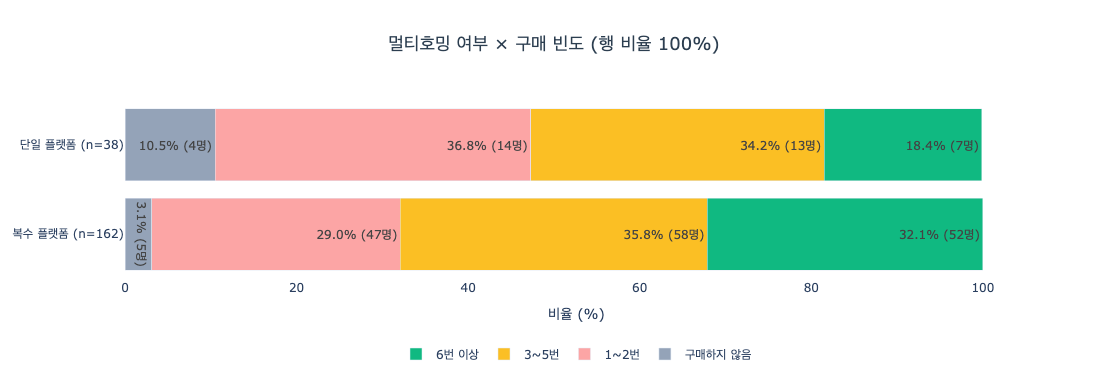

In [27]:
PURCH_ORDER = ['구매하지 않음', '1~2번', '3~5번', '6번 이상']
PURCH_COLOR = ['#94A3B8', '#FCA5A5', '#FBBF24', '#10B981']

cross_pp = (
    pd.crosstab(df['platform_group'], df['purchase_count'])
    .reindex([1, 2])[PURCH_ORDER]
)
cross_pp_pct = (cross_pp.div(cross_pp.sum(axis=1), axis=0) * 100).round(1)

fig = go.Figure()
for i, level in enumerate(PURCH_ORDER):
    fig.add_trace(go.Bar(
        name=level,
        y=[f'단일 플랫폼 (n={cross_pp.loc[1].sum()})', f'복수 플랫폼 (n={cross_pp.loc[2].sum()})'],
        x=cross_pp_pct[level],
        orientation='h',
        marker_color=PURCH_COLOR[i],
        text=[f"{p}% ({int(n)}명)" for p, n in zip(cross_pp_pct[level], cross_pp[level])],
        textposition='inside',
    ))

fig.update_layout(
    title=dict(text='멀티호밍 여부 × 구매 빈도 (행 비율 100%)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='stack',
    xaxis_title='비율 (%)',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=380,
    legend=dict(orientation='h', yanchor='bottom', y=-0.5, xanchor='center', x=0.5),
)
fig.show()

In [28]:
# 구매 빈도 × 멀티호밍 그룹 Mann-Whitney U 검정
PURCH_RANK = {'구매하지 않음': 0, '1~2번': 1, '3~5번': 2, '6번 이상': 3}
purch_1 = df[df['platform_group'] == 1]['purchase_count'].map(PURCH_RANK)
purch_2 = df[df['platform_group'] == 2]['purchase_count'].map(PURCH_RANK)

u_stat_p, p_mw_p = stats.mannwhitneyu(purch_1, purch_2, alternative='two-sided')
n1_p, n2_p = len(purch_1), len(purch_2)
r_rb_p = 1 - (2 * u_stat_p) / (n1_p * n2_p)

print(f'n1 (단일) = {n1_p}, n2 (멀티호밍) = {n2_p}')
print(f'Mann-Whitney U = {u_stat_p:.1f}, p-value = {p_mw_p:.4f}')
print(f'rank-biserial r = {r_rb_p:.3f}')

n1 (단일) = 38, n2 (멀티호밍) = 162
Mann-Whitney U = 2414.0, p-value = 0.0295
rank-biserial r = 0.216


### 분석 질문 4-2 결과: 복수 플랫폼 그룹의 추천 의향이 상대적으로 높고 구매 빈도도 소폭 높음
_교차 SQL: `platform_group_by_nps` (GROUP BY) · 검정: scipy 만-휘트니 U_


NPS 세그먼트 구성과 추천점수 원점수는 같은 Q15를 서로 다른 해상도로 보여준다. 구매 빈도는 별도의 행동 신호로 함께 본다.

**NPS 세그먼트 구성**

| 그룹 | Detractor | Passive | Promoter | n |
|---|---|---|---|---|
| 단일 | **60.5% (23명)** | 31.6% (12명) | 7.9% (3명) | 38 |
| 복수 플랫폼 | **40.1% (65명)** | **46.9% (76명)** | 13.0% (21명) | 162 |
| 차이 (복수−단일) | **−20.4%p** | **+15.3%p** | +5.1%p | — |

**추천점수 원점수 (Mann-Whitney U)**

| 지표 | 단일 플랫폼 | 복수 플랫폼 | 차이 / 결과 |
|------|------------|------------|-------------|
| n | 38 | 162 | 200 |
| 평균 추천점수 | 5.74 | **6.63** | **+0.89점** |
| 중앙값 추천점수 | 6.0 | 7.0 | +1.0점 |
| Mann-Whitney U | — | — | **U=2327.0, p=0.0176** |
| rank-biserial r | — | — | **0.244 (작음)** |

**구매 빈도 (Mann-Whitney U)**

구매 빈도는 복수 플랫폼 그룹의 순위 분포가 단일 플랫폼보다 약간 높으며(U=2414.0, p=0.0295), 효과 크기는 작다(rank-biserial r=0.216).

| 구매 빈도 | 단일 플랫폼 (n=38) | 복수 플랫폼 (n=162) | 차이 |
|----------|-------------------|---------------------|-----|
| 구매하지 않음 | 10.5% (4명) | 3.1% (5명) | -7.4%p |
| 1~2번 | 36.8% (14명) | 29.0% (47명) | -7.8%p |
| 3~5번 | 34.2% (13명) | 35.8% (58명) | +1.6%p |
| **6번 이상** | **18.4% (7명)** | **32.1% (52명)** | **+13.7%p** |

> ### 섹션 결론
> - 단일 플랫폼 사용자의 Detractor 비중은 **60.5%** 로 복수 플랫폼 사용자 **40.1%** 보다 높다.
> - 복수 플랫폼 사용자의 추천점수 분포는 단일 플랫폼 사용자보다 상대적으로 높다(U=**2327.0**, p=**0.0176**, r=**0.244**). 평균 추천점수는 각각 **6.63점**, **5.74점** 이다.
> - 구매 빈도는 복수 플랫폼 그룹이 단일 플랫폼보다 약간 높으며(U=**2414.0**, p=**0.0295**, r=**0.216**, 작음), 6번 이상 구매 비율은 복수 플랫폼 **32.1%**, 단일 플랫폼 **18.4%** 다.
> - 이 결과는 멀티호밍의 인과 효과가 아니라 그룹 간 구성·태도·행동 차이를 보여주는 후속 관찰 신호로 해석한다.

---

## 결론 및 핵심 인사이트

인지 경로에서는 SNS가 **42.0%** 로 가장 높았고, 구매 영향에서는 SNS **35.5%** 와 유튜브 **24.5%** 가 높은 비중을 차지했다. 특히 유튜브는 인지 **11.5%** 보다 구매 영향 응답 비중이 컸고, 친구/지인은 인지보다 구매 영향에서 비중이 작았다. 멀티호밍 분석에서는 복수 플랫폼 사용자가 81.0%로 다수였으며, 복수 플랫폼 그룹의 추천점수·구매 빈도 순위가 상대적으로 높았지만 효과 크기는 작았다.

---

### 통계/기술 분석 요약

주요 분포는 기술통계로 정리하고, 섹션 3과 4-2에서 분석 질문에 필요한 검정만 제한적으로 사용했다. 성별·연령 차이는 소표본 보조 관찰로 남겼다.

| 섹션 | 분석 방법 | 결과 |
|---|---|---|
| 1·2 — 채널 분포 | 응답자 수·비율 | SNS·유튜브·포털 인지 72.0%, SNS·유튜브 구매 영향 60.0% |
| 3 — 동일 채널 응답률 | 카이제곱 3×2 | Chi²=18.447, df=2, **p<0.001**, V=0.345, n=155 |
| 4-1 — 멀티호밍 분포 | 응답자 수·비율 | 복수 플랫폼 81.0%, 단일 플랫폼 19.0% |
| 4-2 — NPS 세그먼트 | 그룹별 비율 | 단일 플랫폼 Detractor 60.5%; 복수 플랫폼 40.1% |
| 4-2 — 추천점수 | Mann-Whitney U | U=2327.0, **p=0.0176**, r=0.244 |
| 4-2 — 구매 빈도 | Mann-Whitney U | U=2414.0, **p=0.0295**, r=0.216 (작음) |

---

### 핵심 발견 요약

- **발견 1:** SNS·유튜브·포털은 전체 인지의 72.0%이며, 친구/지인은 인지보다 구매 영향 단계에서 비중이 작다.
- **발견 2:** 공통 3채널의 동일 채널 응답률은 인지 채널에 따라 차이가 있으며, 친구/지인이 낮다.
- **발견 3:** 복수 플랫폼 사용자가 81.0%로 다수이며, 복수 플랫폼 그룹의 추천 의향·구매 빈도 순위가 상대적으로 높지만 효과 크기는 작다.

---

> 발견별 상세 근거·해석은 각 섹션의 `섹션 결론`을, 통계 방법론은 [docs/METHODS.md](../docs/METHODS.md)를 참조한다.

---

✅ **후속 모니터링 지표 (제안)**

| 지표 | 정의 | 현재 설문 기준선 | 관찰 방향 | 주기 | 비고 |
|-----|------|------------|------------|------|------|
| SNS·유튜브·포털 인지 비중 | (SNS+유튜브+포털 인지자) / 전체 사용자 | 72.0% | 추이 관찰 | 분기 | 실제 유입 로그와 병행 |
| SNS·유튜브 동일 채널 응답률 | SNS·유튜브 인지자 중 동일 채널을 구매 영향으로 응답한 비율 | 57.9% (62/107) | 유지·변화 관찰 | 분기 | 회상 기반 설문 지표 |
| 단일 플랫폼 사용자 Detractor 비율 | 단일 플랫폼 사용자 중 추천점수 0-6 응답자 비율 | 60.5% | 감소 여부 관찰 | 반기 | 정기 NPS 설문 활용 |

> 현재값은 단일 시점 설문 기준선이다. 반복 측정 전에는 목표치로 사용하지 않고 실제 유입·노출·구매 로그와 함께 추이를 확인한다.

✅ **후속 작업 제안**

- **채널 경로 로그 연결** — SNS·유튜브 유입자의 노출·방문·구매 로그를 연결해 설문에서 관찰한 동일 채널 응답률이 실제 경로에서도 나타나는지 확인한다.
- **채널 연속성 A/B 후보** — 실제 SNS·유튜브 유입자를 일반 랜딩(A)과 유입 콘텐츠 맥락을 반영한 랜딩(B)에 무작위 배정하고, 상품 상세 진입률을 1차 지표로 비교한다.
- **단일 플랫폼 그룹 반복 관찰** — Detractor 비율 60.5%가 반복 NPS와 구매 로그에서도 유지되는지 확인한 뒤 온보딩·탐색 개선 여부를 검토한다.

⚠️ **인과 추론 한계**
- 본 분석은 단면 데이터 기반이므로 채널·멀티호밍과 NPS·구매 행동의 인과 방향을 확정할 수 없다.
- 멀티호밍은 무작위 배정할 수 없으므로 코호트 관찰 대상으로 두고, A/B는 채널 랜딩처럼 실제로 배정 가능한 요소에만 적용한다.


---

### SQL 기법 매핑

이 노트북에서 각 분석을 산출한 SQL 쿼리와 기법(검정·다중응답·NLP는 pandas).

| 섹션 | SQL 쿼리 | 기법 |
|------|---------|------|
| 1 인지 경로 분포 | `discovery_dist` | GROUP BY · 윈도우 |
| 2 구매 영향 분포 | `influence_dist` | GROUP BY · 윈도우 |
| 성별·연령 × 채널 | `*_by_gender`·`age_by_channel_type` | GROUP BY |
| 3 인지=영향 일치 | `channel_match` | 조건부 집계 (검정 scipy 카이제곱) |
| 4 멀티호밍 × NPS/구매 | `platform_group_*` | GROUP BY (검정 scipy 만-휘트니) |
